In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the cleaned CSV from your preprocessing folder
file_path = r"../data_preprocessing/cleaned_telco_churn.csv"
df = pd.read_csv(file_path)

# Just in case customerID is still in there, drop it so it doesn't confuse the model
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# 2. Re-create X (features) and y (target)
X = df.drop('Churn', axis=1)

# Prevent Data Leakage: Drop Churn_Binary if it was accidentally saved in the CSV
if 'Churn_Binary' in X.columns:
    X = X.drop('Churn_Binary', axis=1)

# One-hot encode the categorical text into binary 1s and 0s
X = pd.get_dummies(X, drop_first=True) 

# Convert the target variable from 'Yes'/'No' text to 1/0 integers
y = df['Churn'].map({'Yes': 1, 'No': 0}) 

print(f"Data loaded successfully! Features shape: {X.shape}")

# 3. Split the data into a Training set (80%) and a Testing set (20%)
# We train the model on the 80%, and test it on the 20% it has never seen before.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Random Forest Model
# Think of this as planting 100 different "decision trees" that will vote on whether a customer leaves.
print("\nTraining the Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Make Predictions on the Test Set and Evaluate
y_pred = rf_model.predict(X_test)

print("\n--- Model Evaluation ---")
print(f"Overall Accuracy: {round(accuracy_score(y_test, y_pred) * 100, 2)}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 6. BUSINESS VALUE: Predicting the exact probability of a customer leaving
# predict_proba gives us the % chance [Stay, Leave] for each customer
probabilities = rf_model.predict_proba(X_test)[:, 1] # Grab just the index 1 ("Leave") probability

# Let's look at the first 5 customers in our test set
print("\nChurn Probability for first 5 test customers:")
for i in range(5):
    print(f"Customer {i+1}: {round(probabilities[i] * 100, 2)}% risk of churning")

Data loaded successfully! Features shape: (7043, 30)

Training the Random Forest Model...

--- Model Evaluation ---
Overall Accuracy: 78.92%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409


Churn Probability for first 5 test customers:
Customer 1: 80.0% risk of churning
Customer 2: 8.0% risk of churning
Customer 3: 2.0% risk of churning
Customer 4: 74.0% risk of churning
Customer 5: 5.0% risk of churning


In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("\n--- Phase 2: Hyperparameter Tuning with GridSearchCV ---")
print("Running GridSearchCV to find the best model (This might take a minute)...")

# Define the "grid" of settings we want to test
param_grid = {
    'n_estimators': [100, 200],      # Try 100 trees, then 200 trees
    'max_depth': [10, None],         # Try limiting the depth of the trees so they don't overfit
    'class_weight': ['balanced']     # CRITICAL: Forces the model to penalize missing a churner heavily
}

# Initialize a base Random Forest
base_rf = RandomForestClassifier(random_state=42)

# Set up the Grid Search to optimize specifically for 'recall' (catching the 1s)
grid_search = GridSearchCV(estimator=base_rf, param_grid=param_grid, cv=3, scoring='recall', n_jobs=-1)

# Run the training combinations!
grid_search.fit(X_train, y_train)

# Extract the Best Model and Evaluate
best_rf_model = grid_search.best_estimator_
print(f"\nBest Parameters Found: {grid_search.best_params_}")

y_pred_tuned = best_rf_model.predict(X_test)

print("\n--- TUNED Model Evaluation ---")
print(f"Overall Accuracy: {round(accuracy_score(y_test, y_pred_tuned) * 100, 2)}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_tuned))


--- Phase 2: Hyperparameter Tuning with GridSearchCV ---
Running GridSearchCV to find the best model (This might take a minute)...

Best Parameters Found: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 100}

--- TUNED Model Evaluation ---
Overall Accuracy: 76.86%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1036
           1       0.54      0.81      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



ROC-AUC Score: 0.8614 (Closer to 1.0 is better!)


c:\Users\jeffy\mlproject\mlenv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


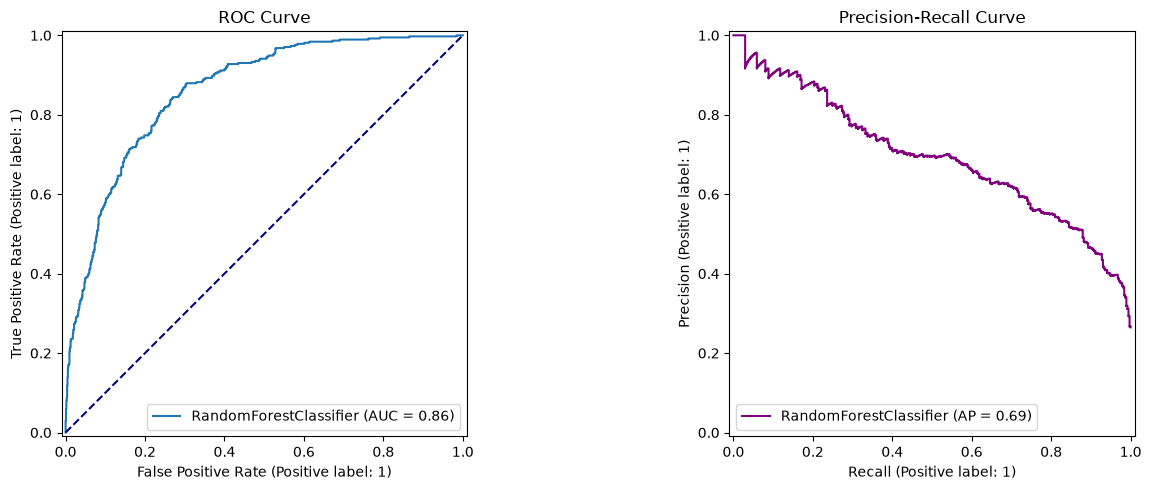

In [5]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# 1. Calculate ROC-AUC Score
y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f} (Closer to 1.0 is better!)")

# 2. Plot the Curves side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_estimator(best_rf_model, X_test, y_test, ax=ax1)
ax1.set_title('ROC Curve')
ax1.plot([0, 1], [0, 1], color='navy', linestyle='--') # Add diagonal random guessing line

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(best_rf_model, X_test, y_test, ax=ax2, color='purple')
ax2.set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

In [6]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# XGBoost doesn't use 'class_weight="balanced"'. 
# Instead, we calculate the exact ratio of Stayers (0) to Leavers (1) in our training data.
weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated Weight Ratio for XGBoost: {round(weight_ratio, 2)}")

# 'scale_pos_weight' acts just like our balanced class weight to catch churners.
xgb_model = XGBClassifier(
    scale_pos_weight=weight_ratio, 
    random_state=42,
    learning_rate=0.1,     # How aggressive it fixes mistakes (0.1 is a safe default)
    max_depth=5,           # Limiting depth prevents it from memorizing the data (overfitting)
    eval_metric='logloss'
)

print("\nTraining XGBoost Model...")
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\n--- XGBoost Model Evaluation ---")
print(f"Overall Accuracy: {round(accuracy_score(y_test, y_pred_xgb) * 100, 2)}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Calculated Weight Ratio for XGBoost: 2.77

Training XGBoost Model...

--- XGBoost Model Evaluation ---
Overall Accuracy: 76.08%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1036
           1       0.53      0.80      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [8]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# We recalculate the weight ratio just to be safe
weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated Weight Ratio for XGBoost: {round(weight_ratio, 2)}")

# Set up the base model with the balanced weight
base_xgb = XGBClassifier(
    scale_pos_weight=weight_ratio, 
    random_state=42,
    eval_metric='logloss'
)

print("\n--- Phase 3: Hyperparameter Tuning XGBoost ---")
print("Setting up GridSearchCV for XGBoost...")

# The hyperparameter grid specifically designed for XGBoost
xgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1], # How aggressive it fixes mistakes (0.01 is slow/careful, 0.1 is fast)
    'max_depth': [3, 5, 7],             # Depth of the tree (3 is shallow/safe against overfitting, 7 is deep)
    'n_estimators': [100, 200]          # Number of sequential trees to build
}

xgb_grid = GridSearchCV(
    estimator=base_xgb, 
    param_grid=xgb_param_grid, 
    cv=3, 
    scoring='recall', # Still strictly optimizing to catch the churners!
    n_jobs=-1
)

print("Training tuned XGBoost Model (This will take 30-60 seconds)...")
xgb_grid.fit(X_train, y_train)

# Get the best model from the grid search
best_xgb = xgb_grid.best_estimator_
print(f"\nBest XGBoost Parameters: {xgb_grid.best_params_}")

# Make predictions with the newly tuned model
y_pred_xgb_tuned = best_xgb.predict(X_test)

print("\n--- TUNED XGBoost Model Evaluation ---")
print(f"Overall Accuracy: {round(accuracy_score(y_test, y_pred_xgb_tuned) * 100, 2)}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb_tuned))

Calculated Weight Ratio for XGBoost: 2.77

--- Phase 3: Hyperparameter Tuning XGBoost ---
Setting up GridSearchCV for XGBoost...
Training tuned XGBoost Model (This will take 30-60 seconds)...

Best XGBoost Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

--- TUNED XGBoost Model Evaluation ---
Overall Accuracy: 73.81%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.69      0.80      1036
           1       0.50      0.87      0.64       373

    accuracy                           0.74      1409
   macro avg       0.72      0.78      0.72      1409
weighted avg       0.82      0.74      0.75      1409



In [1]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE # The new synthetic data library!

# 1. Load the cleaned CSV
file_path = r"../data_preprocessing/cleaned_telco_churn.csv"
df = pd.read_csv(file_path)

if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

print("--- Step 1: Feature Engineering ---")
# Let's create a new column to see if they are being hit with hidden/extra fees over time.
# If TotalCharges is way higher than (MonthlyCharges * Tenure), something is wrong.
df['Extra_Charges_Fee'] = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])

# Create a column for "Is a New Customer" (less than 6 months tenure)
df['Is_New_Customer'] = (df['tenure'] <= 6).astype(int)

# 2. Re-create X and y
X = df.drop(['Churn'], axis=1)
if 'Churn_Binary' in X.columns:
    X = X.drop('Churn_Binary', axis=1)
X = pd.get_dummies(X, drop_first=True) 

y = df['Churn'].map({'Yes': 1, 'No': 0}) 

# 3. Train/Test Split
# CRITICAL: We split BEFORE using SMOTE. We never want fake data in our test set!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n--- Step 2: Applying SMOTE (Synthetic Data) ---")
print(f"Original Training data shapes: Stayers={(y_train==0).sum()}, Leavers={(y_train==1).sum()}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"SMOTE Training data shapes: Stayers={(y_train_smote==0).sum()}, Leavers={(y_train_smote==1).sum()}")
print("Notice how SMOTE perfectly balanced the classes to 50/50!")

print("\n--- Step 3: F1-Optimized XGBoost ---")
# Because SMOTE made our data 50/50, we NO LONGER need scale_pos_weight!
base_xgb = XGBClassifier(random_state=42, eval_metric='logloss')

xgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1], 
    'max_depth': [3, 5, 7],             
    'n_estimators': [100, 200]          
}

# We change scoring to 'f1' to balance Precision and Recall, boosting overall Accuracy.
xgb_grid = GridSearchCV(
    estimator=base_xgb, 
    param_grid=xgb_param_grid, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1
)

print("Training Advanced XGBoost Model (This will take a minute)...")
xgb_grid.fit(X_train_smote, y_train_smote)

best_xgb_advanced = xgb_grid.best_estimator_
print(f"\nBest Advanced Parameters: {xgb_grid.best_params_}")

y_pred_advanced = best_xgb_advanced.predict(X_test)

print("\n--- FINAL ADVANCED MODEL EVALUATION ---")
print(f"Overall Accuracy: {round(accuracy_score(y_test, y_pred_advanced) * 100, 2)}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_advanced))

--- Step 1: Feature Engineering ---

--- Step 2: Applying SMOTE (Synthetic Data) ---
Original Training data shapes: Stayers=4138, Leavers=1496
SMOTE Training data shapes: Stayers=4138, Leavers=4138
Notice how SMOTE perfectly balanced the classes to 50/50!

--- Step 3: F1-Optimized XGBoost ---
Training Advanced XGBoost Model (This will take a minute)...

Best Advanced Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}

--- FINAL ADVANCED MODEL EVALUATION ---
Overall Accuracy: 78.78%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1036
           1       0.58      0.69      0.63       373

    accuracy                           0.79      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.79      0.79      1409



In [3]:
from sklearn.metrics import accuracy_score, recall_score, precision_score
import numpy as np

# 1. Get the raw percentages (probabilities) instead of the hard 1s and 0s
# (Assuming 'best_xgb_advanced' is still in your notebook's memory from the last cell)
probabilities = best_xgb_advanced.predict_proba(X_test)[:, 1]

print("--- Custom Threshold Tuning ---")
print(f"{'Threshold':<12} | {'Accuracy':<10} | {'Recall':<10} | {'Precision':<10}")
print("-" * 50)

# 2. Test different cutoffs from 30% to 70%
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for thresh in thresholds:
    # If the probability is greater than our custom threshold, predict 1. Otherwise, 0.
    custom_predictions = (probabilities >= thresh).astype(int)
    
    # Calculate the new metrics
    acc = accuracy_score(y_test, custom_predictions)
    rec = recall_score(y_test, custom_predictions)
    prec = precision_score(y_test, custom_predictions)
    
    print(f"{thresh:>9.2f}   | {acc:>8.2%}   | {rec:>8.2%}   | {prec:>8.2%}")

print("-" * 50)
print("Look at the tradeoff! As the threshold goes down, Recall goes UP, but Precision/Accuracy go DOWN.")

--- Custom Threshold Tuning ---
Threshold    | Accuracy   | Recall     | Precision 
--------------------------------------------------
     0.30   |   69.48%   |   86.60%   |   45.95%
     0.35   |   72.46%   |   82.84%   |   48.82%
     0.40   |   75.37%   |   78.28%   |   52.33%
     0.45   |   77.36%   |   74.26%   |   55.40%
     0.50   |   78.78%   |   68.63%   |   58.45%
     0.55   |   79.70%   |   61.66%   |   61.66%
     0.60   |   79.99%   |   57.10%   |   63.58%
--------------------------------------------------
Look at the tradeoff! As the threshold goes down, Recall goes UP, but Precision/Accuracy go DOWN.
